# 20 — Pilota del few-shot: k e variante di prompt

Sceglie la configurazione del notebook 21 (`qwen_fewshot`) prima di spendere ~15 h di
generazione sul test. Rifà, con un'impostazione corretta, l'esplorazione di Federica in
`notebooks/llm/20_preliminary_fs_test.ipynb` (archiviata con i suoi output), di cui tiene i
risultati come punto di partenza:

- **embedding**: solo `all-mpnet-base-v2` (`sbert_mpnet_en`), il migliore dei quattro nel suo
  pilota (TF-IDF, SBERT multilingue, SBERT inglese, `nomic-embed-text`); non si rifà il
  confronto, le differenze fra embedding erano minime;
- **griglia**: k ∈ {2, 4} × prompt {`old`, `new`}, più k=6 con `new` (aggiunto dopo, vedi la
  Conclusione) (la variante `structured` era la peggiore su
  ROUGE e METEOR ed è scartata), più il **controllo k=0**: il prompt zero-shot del notebook 07,
  mandato con la stessa pipeline (API nativa, `num_ctx`). Il confronto con k=0 isola l'effetto
  degli esempi da quello di tutto il resto;
- **baseline retrieval-only**: il riassunto del 1° vicino usato *come* riassunto. Misura quanto
  il retrieval da solo si avvicina al riferimento — se molto, il few-shot rischia di copiare la
  notizia gemella del train invece di riassumere il documento.

Tre cose che il pilota originale non controllava e questo sì:
1. **Righe di validation, non test né campione.** Il campione condiviso contiene righe del
   train, che ritroverebbero se stesse come esempio; pilotare sul test vorrebbe dire scegliere
   la configurazione guardando i dati su cui la si valuta. Qui: 100 righe della split `val`
   (seed 42); il pool degli esempi è il train, come nel notebook 21.
2. **Contesto di ollama.** I prompt con k=4 arrivano a decine di migliaia di token; il pilota
   originale usava l'endpoint di default, che su versioni/macchine con contesto piccolo li
   tronca in silenzio. Qui `num_ctx=32768` e una richiesta che satura il contesto fallisce
   (`su.genera_ollama_nativo`).
3. **Rumore.** Con 100 righe l'errore standard di ROUGE-1 F1 è ~0,009: la scelta si fa sulle
   differenze appaiate (rispetto a k=0 e fra configurazioni) con il loro IC 95%, non su un
   punteggio composito normalizzato min-max (che amplifica differenze dentro il rumore).

**Esito** (vedi la Conclusione): k=4, prompt `new`.

In [1]:
# --- Configurazione ---------------------------------------------------------
import json
import os
import random

import summ_utils as su

# PILOTA_N=3 per uno smoke test: gli output vanno in una cartella propria (pilota_val3/)
N_PILOTA   = int(os.environ.get('PILOTA_N', 100))
SEED       = 42
MODELLO    = 'qwen2.5:7b-instruct'
MAX_TOKENS = 200          # come i notebook 07 e 21
TEMPERATURE = 0.3
K_MAX      = 6
K_RUMORE   = 4          # vicini su cui si misura il rumore di fondo della contaminazione (k0)
CONFIGURAZIONI = {'k0': (0, None),
                  'k2_old': (2, 'old'), 'k2_new': (2, 'new'),
                  'k4_old': (4, 'old'), 'k4_new': (4, 'new'),
                  # aggiunto il 2026-09-28: l'unico k del pilota di Federica mai provato con il
                  # contesto corretto (nel suo era il piu' troncato)
                  'k6_new': (6, 'new')}

BASE = su.trova_base_dir()
P    = su.percorsi_standard(BASE)
PILOTA_DIR  = BASE / 'results' / 'fewshot' / f'pilota_val{N_PILOTA}'
VICINI_PATH = PILOTA_DIR / 'vicini.tsv'
CACHE_EMB   = BASE / 'results' / 'embeddings_cache'
RISULTATI_PATH = PILOTA_DIR / 'riepilogo.json'

# Controllo k=0: il prompt zero-shot del notebook 07, letto dalla config della sua corsa
# sul test cosi' e' per costruzione lo stesso testo
_cfg07 = json.load(open(P['metrics_dir'] / 'qwen_test_aggregate.json', encoding='utf-8'))['config']
PROMPT_SYSTEM_07, PROMPT_USER_07 = _cfg07['prompt_system'], _cfg07['prompt_user']

righe_val = list(su.itera_split(P['complete_tab'], 'val'))
righe = sorted(random.Random(SEED).sample(righe_val, N_PILOTA), key=lambda r: r['row_id'])
del righe_val
print(f'{len(righe)} righe di validation, row_id {righe[0]["row_id"]}..{righe[-1]["row_id"]}')

100 righe di validation, row_id 44933..50488


## Retrieval

In [2]:
# Si ricalcola se il TSV ha meno di K_MAX vicini per riga (es. dopo l'aggiunta di k=6): i primi
# vicini non cambiano, perche' il coseno esatto e' deterministico
if VICINI_PATH.exists() and min(len(v) for v in su.carica_vicini(VICINI_PATH).values()) >= K_MAX:
    VICINI = su.carica_vicini(VICINI_PATH)
else:
    VICINI = su.calcola_vicini(P['complete_tab'], righe, K_MAX, CACHE_EMB,
                               f'pilota_val{N_PILOTA}', VICINI_PATH)
ESEMPI_TRAIN = su.carica_esempi_train(P['complete_tab'],
                                      {v for r in righe for v, _ in VICINI[r['row_id']]})
# Riassunto del 1o vicino, intero (per la baseline retrieval-only)
PRIMO_VICINO = {r['row_id']: ESEMPI_TRAIN[VICINI[r['row_id']][0][0]]['summary'] for r in righe}

[train] embedding dalla cache (train_all-mpnet-base-v2_2e3005dfe4559857.npy)
[pilota_val100] embedding dalla cache (pilota_val100_all-mpnet-base-v2_d76c890208bbbd19.npy)


Vicini: C:\Users\antonio.girasella\source\repos\multi-news-ai4stem-polito-master\results\fewshot\pilota_val100\vicini.tsv (100 righe x 6)


## Generazione

Un TSV per configurazione in `results/fewshot/pilota_val100/`, con la stessa ripresa dei notebook
dei metodi: rieseguire la cella completa solo le righe mancanti.

In [3]:
TOKEN_PROMPT = {c: [] for c in CONFIGURAZIONI}

def messaggi(es, k, variante):
    documento = su.tronca_parole(su.prepara_documento(es['document']),
                                 su.MAX_PAROLE_DOCUMENTO_FEWSHOT)
    if k == 0:
        return [{'role': 'system', 'content': PROMPT_SYSTEM_07},
                {'role': 'user', 'content': PROMPT_USER_07.format(documento=documento)}]
    esempi = [ESEMPI_TRAIN[v] for v, _ in VICINI[es['row_id']][:k]]
    return [{'role': 'user', 'content': su.prompt_fewshot(esempi, documento, variante)}]

for nome, (k, variante) in CONFIGURAZIONI.items():
    # Il "documento" passato al ciclo e' la lista di messaggi gia' pronta
    def righe_config():
        for es in righe:
            yield {**es, 'document': messaggi(es, k, variante)}

    def genera(msg, nome=nome):
        testo, n = su.genera_ollama_nativo(msg, MODELLO, MAX_TOKENS, TEMPERATURE)
        TOKEN_PROMPT[nome].append(n)
        return testo

    scrittore = su.ScrittoreRiassunti(PILOTA_DIR / f'{nome}.tsv')
    su.ciclo_summarization(righe_config(), scrittore, genera, etichetta=f'{nome} ',
                           prepara=lambda m: m)
    scrittore.chiudi()

for nome, t in TOKEN_PROMPT.items():
    if t:
        t = sorted(t)
        print(f'{nome:7s} token del prompt: mediana {t[len(t) // 2]}, max {t[-1]}')

k0 Completato: 0 nuovi, 100 saltati, 0 errori, 0 s totali
k2_old Completato: 0 nuovi, 100 saltati, 0 errori, 0 s totali
k2_new Completato: 0 nuovi, 100 saltati, 0 errori, 0 s totali
k4_old Completato: 0 nuovi, 100 saltati, 0 errori, 0 s totali
k4_new Completato: 0 nuovi, 100 saltati, 0 errori, 0 s totali


k6_new [1] media 18.2 s/esempio (saltati 0 gia' fatti)


k6_new [2] media 14.6 s/esempio (saltati 0 gia' fatti)


k6_new [3] media 13.0 s/esempio (saltati 0 gia' fatti)


k6_new [10] media 11.7 s/esempio (saltati 0 gia' fatti)


...

k6_new [60] media 11.7 s/esempio (saltati 0 gia' fatti)


k6_new [70] media 11.7 s/esempio (saltati 0 gia' fatti)


k6_new [80] media 11.5 s/esempio (saltati 0 gia' fatti)


k6_new [90] media 11.4 s/esempio (saltati 0 gia' fatti)


k6_new [100] media 11.4 s/esempio (saltati 0 gia' fatti)
k6_new Completato: 100 nuovi, 0 saltati, 0 errori, 1138 s totali
k6_new  token del prompt: mediana 10766, max 23261


## Metriche

Stesse metriche del benchmark (`su.metriche_esempio`) più BERTScore (`roberta-large`). Per
ogni configurazione: media ± errore standard, e differenza **appaiata** rispetto a k=0 (stesse
righe) con IC 95%.

In [4]:
import numpy as np
import pandas as pd

valutatore = su.crea_valutatore()
riferimenti = {r['row_id']: su.pulisci_riferimento(r['summary']) for r in righe}
predizioni = {nome: su.carica_riassunti(PILOTA_DIR / f'{nome}.tsv') for nome in CONFIGURAZIONI}
predizioni['retrieval_only'] = PRIMO_VICINO

coppie, righe_metriche = [], []
for nome, pred in predizioni.items():
    for rid, testo in pred.items():
        righe_metriche.append({'config': nome, 'row_id': rid,
                               **su.metriche_esempio(valutatore, testo, riferimenti[rid])})
        coppie.append((f'{nome}|{rid}', testo, riferimenti[rid]))
bs = su.calcola_bertscore_batch(coppie)
df = pd.DataFrame(righe_metriche)
df['bertscore_f1'] = [bs[f'{c}|{r}']['bertscore_f1'] for c, r in zip(df.config, df.row_id)]

METRICHE = ['rouge1_f1', 'rouge2_f1', 'rougeL_f1', 'meteor', 'bertscore_f1', 'parole_generate']
ordine = list(predizioni)
media = df.groupby('config')[METRICHE].mean().loc[ordine]
se = (df.groupby('config')[METRICHE].std() / np.sqrt(df.groupby('config').size().values[:, None])).loc[ordine]
print('Media (n per configurazione:', dict(df.groupby('config').size()), ')')
print(media.round(4).to_string())
print('\nErrore standard')
print(se.round(4).to_string())

C:\Users\antonio.girasella\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:  90%|█████████ | 352/389 [00:00<00:00, 3515.34it/s]

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 3568.09it/s]


[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Media (n per configurazione: {'k0': np.int64(100), 'k2_new': np.int64(100), 'k2_old': np.int64(100), 'k4_new': np.int64(100), 'k4_old': np.int64(100), 'k6_new': np.int64(100), 'retrieval_only': np.int64(100)} )
                rouge1_f1  rouge2_f1  rougeL_f1  meteor  bertscore_f1  parole_generate
config                                                                                
k0                 0.3393     0.1071     0.1909  0.3257        0.8636           128.90
k2_old             0.3487     0.1136     0.1960  0.3432        0.8654           138.33
k2_new             0.3510     0.1131     0.1985  0.3168        0.8675           116.61
k4_old             0.3547     0.1183     0.1979  0.3512        0.8643           141.70
k4_new             0.3537     0.1195     0.2005  0.3154        0.8686           113.62
k6_new             0.3506     0.1159     0.1963  0.3174        0.8679           117.23
retrieval_only     0.2542     0.0425     0.1363  0.3226        0.8335           223.07

Error

In [5]:
# Differenze appaiate rispetto al controllo k=0, sulle righe comuni
base = df[df.config == 'k0'].set_index('row_id')
diff = {}
for nome in ordine:
    if nome == 'k0':
        continue
    alt = df[df.config == nome].set_index('row_id')
    comuni = base.index.intersection(alt.index)
    d = alt.loc[comuni, METRICHE[:-1]] - base.loc[comuni, METRICHE[:-1]]
    diff[nome] = {m: (d[m].mean(), 1.96 * d[m].std() / np.sqrt(len(d))) for m in d}
    print(f'{nome:15s} n={len(comuni)}  ' + '  '.join(
        f'{m}: {mu:+.4f} ±{ic:.4f}' for m, (mu, ic) in diff[nome].items() if m in ('rouge1_f1', 'bertscore_f1', 'meteor')))

k2_old          n=100  rouge1_f1: +0.0094 ±0.0100  meteor: +0.0175 ±0.0092  bertscore_f1: +0.0018 ±0.0021
k2_new          n=100  rouge1_f1: +0.0116 ±0.0103  meteor: -0.0089 ±0.0105  bertscore_f1: +0.0039 ±0.0020
k4_old          n=100  rouge1_f1: +0.0154 ±0.0107  meteor: +0.0255 ±0.0114  bertscore_f1: +0.0007 ±0.0034
k4_new          n=100  rouge1_f1: +0.0143 ±0.0111  meteor: -0.0103 ±0.0117  bertscore_f1: +0.0050 ±0.0023
k6_new          n=100  rouge1_f1: +0.0113 ±0.0099  meteor: -0.0083 ±0.0119  bertscore_f1: +0.0043 ±0.0020
retrieval_only  n=100  rouge1_f1: -0.0851 ±0.0170  meteor: -0.0031 ±0.0207  bertscore_f1: -0.0301 ±0.0038


In [6]:
# Confronti diretti fra configurazioni few-shot (stesse righe): k4 vs k2, new vs old
def diff_appaiata(a, b, m):
    x = (df[df.config == a].set_index('row_id')[m] - df[df.config == b].set_index('row_id')[m]).dropna()
    return x.mean(), 1.96 * x.std() / np.sqrt(len(x))

diff_tra = {}
for a, b in [('k4_old', 'k2_old'), ('k4_new', 'k2_new'), ('k2_new', 'k2_old'), ('k4_new', 'k4_old'),
             ('k6_new', 'k4_new')]:
    diff_tra[f'{a}-{b}'] = {m: diff_appaiata(a, b, m) for m in METRICHE}
    print(f'{a} - {b}: ' + '  '.join(f'{m}: {mu:+.4f} ±{ic:.4f}'
                                     for m, (mu, ic) in diff_tra[f'{a}-{b}'].items()))

k4_old - k2_old: rouge1_f1: +0.0060 ±0.0110  rouge2_f1: +0.0047 ±0.0070  rougeL_f1: +0.0019 ±0.0068  meteor: +0.0079 ±0.0096  bertscore_f1: -0.0012 ±0.0037  parole_generate: +3.3700 ±3.7203
k4_new - k2_new: rouge1_f1: +0.0027 ±0.0109  rouge2_f1: +0.0064 ±0.0088  rougeL_f1: +0.0020 ±0.0074  meteor: -0.0014 ±0.0103  bertscore_f1: +0.0010 ±0.0018  parole_generate: -2.9900 ±3.9756
k2_new - k2_old: rouge1_f1: +0.0023 ±0.0103  rouge2_f1: -0.0005 ±0.0068  rougeL_f1: +0.0025 ±0.0067  meteor: -0.0264 ±0.0100  bertscore_f1: +0.0021 ±0.0017  parole_generate: -21.7200 ±4.3725
k4_new - k4_old: rouge1_f1: -0.0011 ±0.0125  rouge2_f1: +0.0012 ±0.0094  rougeL_f1: +0.0026 ±0.0084  meteor: -0.0358 ±0.0130  bertscore_f1: +0.0043 ±0.0037  parole_generate: -28.0800 ±4.9469
k6_new - k4_new: rouge1_f1: -0.0031 ±0.0113  rouge2_f1: -0.0036 ±0.0081  rougeL_f1: -0.0042 ±0.0077  meteor: +0.0020 ±0.0114  bertscore_f1: -0.0006 ±0.0017  parole_generate: +3.6100 ±4.0877


## Quasi-leakage dal train

Multi-News contiene notizie coperte più volte da cluster diversi: il vicino più simile del
train può essere la *stessa* notizia, con un riassunto umano quasi identico al riferimento.
Due domande: quanto spesso succede (similarità del 1° vicino) e quanto conta (ROUGE della
baseline retrieval-only in funzione della similarità).

          sim1  rouge1_retrieval
count  100.000           100.000
mean     0.748             0.254
std      0.101             0.058
min      0.507             0.142
25%      0.667             0.218
50%      0.761             0.247
75%      0.824             0.288
max      0.942             0.434
sim1 >= 0.8: 33 righe, ROUGE-1 F1 retrieval-only medio 0.289
sim1 >= 0.9: 3 righe, ROUGE-1 F1 retrieval-only medio 0.300
Correlazione (Spearman) sim1 vs ROUGE retrieval-only: 0.539


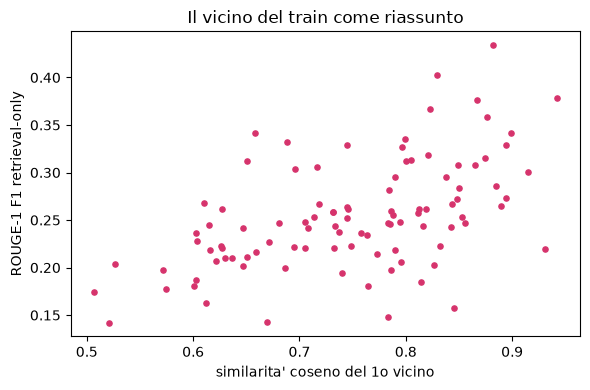

In [7]:
import matplotlib.pyplot as plt

sim1 = pd.Series({r['row_id']: VICINI[r['row_id']][0][1] for r in righe}, name='sim1')
ro = df[df.config == 'retrieval_only'].set_index('row_id')['rouge1_f1'].rename('rouge1_retrieval')
lk = pd.concat([sim1, ro], axis=1)
print(lk.describe().round(3).to_string())
for soglia in (0.8, 0.9):
    sotto = lk[lk.sim1 >= soglia]
    print(f'sim1 >= {soglia}: {len(sotto)} righe, ROUGE-1 F1 retrieval-only medio '
          f'{sotto.rouge1_retrieval.mean():.3f}')
print(f'Correlazione (Spearman) sim1 vs ROUGE retrieval-only: '
      f'{lk.sim1.corr(lk.rouge1_retrieval, method="spearman"):.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(lk.sim1, lk.rouge1_retrieval, s=14, color='#d6336c')
ax.set_xlabel('similarita\' coseno del 1o vicino'); ax.set_ylabel('ROUGE-1 F1 retrieval-only')
ax.set_title('Il vicino del train come riassunto')
plt.tight_layout(); plt.show()

## Contaminazione dagli esempi

Il rischio specifico del few-shot è che il modello riporti nel riassunto fatti degli *esempi*
invece che del documento. Proxy: le parole con l'iniziale maiuscola (nomi propri, per lo più)
del riassunto che compaiono negli esempi usati ma **non** nella sorgente. k0 non vede esempi e fa
da rumore di fondo: gli si confrontano gli stessi 4 vicini, quindi misura le coincidenze casuali
(parole generiche aggiunte dal modello che per caso stanno anche negli esempi).

In [8]:
import re

def parole(t):
    return {w.lower() for w in re.findall(r'\b[A-Za-z]{3,}\b', t)}

def maiuscole(t):
    return set(re.findall(r'\b[A-Z][a-z]{2,}\b', t))

sorgente = {r['row_id']: parole(r['document']) for r in righe}
contaminazione = {}
for nome, (k, _) in CONFIGURAZIONI.items():
    k_ex = k or K_RUMORE   # k0: stessi 4 vicini, come rumore di fondo
    n = []
    for r in righe:
        rid = r['row_id']
        ex = set().union(*(parole(ESEMPI_TRAIN[v]['document'] + ' ' + ESEMPI_TRAIN[v]['summary'])
                           for v, _ in VICINI[rid][:k_ex]))
        n.append(sum(1 for w in maiuscole(predizioni[nome][rid])
                     if w.lower() not in sorgente[rid] and w.lower() in ex))
    contaminazione[nome] = {'media': float(np.mean(n)), 'righe_con_almeno_uno': int(np.sum(np.array(n) > 0))}
    print(f"{nome:7s} parole maiuscole dagli esempi, assenti dalla sorgente: "
          f"{contaminazione[nome]['media']:.2f}/riassunto, righe con almeno una "
          f"{contaminazione[nome]['righe_con_almeno_uno']}/{len(righe)}")

k0      parole maiuscole dagli esempi, assenti dalla sorgente: 0.37/riassunto, righe con almeno una 28/100
k2_old  parole maiuscole dagli esempi, assenti dalla sorgente: 0.39/riassunto, righe con almeno una 31/100
k2_new  parole maiuscole dagli esempi, assenti dalla sorgente: 0.19/riassunto, righe con almeno una 15/100


k4_old  parole maiuscole dagli esempi, assenti dalla sorgente: 0.46/riassunto, righe con almeno una 37/100
k4_new  parole maiuscole dagli esempi, assenti dalla sorgente: 0.18/riassunto, righe con almeno una 15/100


k6_new  parole maiuscole dagli esempi, assenti dalla sorgente: 0.26/riassunto, righe con almeno una 22/100


In [9]:
# Riepilogo su disco (piccolo, committato con i TSV del pilota)
riepilogo = {'righe': 'val', 'n': N_PILOTA, 'seed': SEED, 'modello': MODELLO,
             'num_ctx': su.NUM_CTX_FEWSHOT, 'parole_esempio': su.PAROLE_ESEMPIO_FEWSHOT,
             'embedding': su.MODELLO_EMBEDDING_FEWSHOT,
             'media': media.round(5).to_dict(orient='index'),
             'errore_standard': se.round(5).to_dict(orient='index'),
             'diff_vs_k0': {c: {m: {'media': round(mu, 5), 'ic95': round(ic, 5)}
                                for m, (mu, ic) in v.items()} for c, v in diff.items()},
             'diff_tra_configurazioni': {c: {m: {'media': round(float(mu), 5), 'ic95': round(float(ic), 5)}
                                             for m, (mu, ic) in v.items()} for c, v in diff_tra.items()},
             'contaminazione_esempi': contaminazione,
             'sim1': lk.sim1.describe().round(4).to_dict()}
with open(RISULTATI_PATH, 'w', encoding='utf-8') as f:
    json.dump(riepilogo, f, indent=2, ensure_ascii=False)
print(RISULTATI_PATH)

C:\Users\antonio.girasella\source\repos\multi-news-ai4stem-polito-master\results\fewshot\pilota_val100\riepilogo.json


## Conclusione

**Configurazione scelta per il notebook 21: k=4, prompt `new`** (2026-09-26). È la stessa
della corsa originale di Federica, ora giustificata dai dati.

- **Gli esempi aiutano, di poco.** Rispetto a k=0 tutte le configurazioni guadagnano
  ~0,01–0,015 di ROUGE-1 F1. Solo le due a k=4 escono dall'IC su ROUGE-1 **e** ROUGE-2
  (k4_new: +0,014 ±0,011 e +0,012 ±0,009), e k4_new è anche la migliore su BERTScore
  (+0,005 ±0,002).
- **Fra le quattro configurazioni few-shot nessuna differenza di ROUGE è significativa.**
  k4 vs k2 vale +0,003/+0,006 di ROUGE-1, `new` vs `old` circa zero: la scelta non si
  gioca sull'overlap.
- **`old` contro `new` è una differenza di lunghezza e di fedeltà, non di overlap.**
  - `old` scrive 22–28 parole in più (~140 contro ~115): più recall e più METEOR
    (+0,026/+0,036), per la sola lunghezza.
  - `new` è più corto e più preciso, con BERTScore più alto.
  - Soprattutto, `new` dimezza la contaminazione dagli esempi: 0,18 parole maiuscole
    estranee alla sorgente per riassunto contro 0,46 di k4_old, sotto il rumore di fondo di
    k=0 (0,37). L'istruzione «non usare fatti degli esempi» funziona; `old`, che non ce l'ha,
    resta al livello del rumore o poco sopra.
- **Nessun quasi-leakage dal train.** Il riassunto del vicino più simile, usato come
  risposta, fa 0,254 di ROUGE-1 contro 0,339 di k=0, e anche i 3 vicini con similarità
  ≥ 0,9 si fermano a 0,30. Il retrieval porta esempi di stile, non la notizia gemella.
- **Il contesto non è un problema.** Il prompt più lungo è di 20.281 token contro 32.768,
  con 0 errori su 500 generazioni.
- **Costo.** k=4 costa ~9,5 s/riga contro ~8 di k=2: circa 15 h sul test invece di 12.

Da tenere presente leggendo i risultati sul test: `new` scrive riassunti più corti di
quelli zero-shot (~114 parole contro 129 su queste righe), quindi il confronto con `qwen` va
letto su F1 e precisione, non su recall o METEOR.

**Aggiunta del 2026-09-28: k=6 (prompt `new`).** È l'unico k del pilota di Federica mai provato
con il contesto corretto: nel suo era il più penalizzato dal troncamento a 4k. Non cambia la
scelta. Rispetto a k=4 sta leggermente sotto su tutte le metriche, senza differenze
significative: ROUGE-1 F1 −0,003 ±0,011, ROUGE-2 −0,004 ±0,008, BERTScore −0,001 ±0,002. Riporta
più parole estranee alla sorgente (0,26 contro 0,18). Rispetto a k=0 guadagna +0,011 ±0,010,
meno di k=4. Il beneficio cresce fino a 4 esempi e poi si appiattisce o cala leggermente. I
prompt restano nel contesto (mediana 10.766 token, massimo 23.261, 0 errori). Le configurazioni
già esistenti, rieseguite, danno le stesse metriche al decimale.